<a href="https://colab.research.google.com/github/vigneshwar315/DeepLearning/blob/main/dl_mid2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Lenet
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Conv2D, AveragePooling2D, Flatten
from tensorflow.keras.utils import to_categorical
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255
num_classes = 10
Y_train = to_categorical(y_train, num_classes)
Y_test = to_categorical(y_test, num_classes)

model = Sequential()

model.add(Conv2D(6, kernel_size=(5,5), activation='tanh', input_shape=(28,28,1)))
model.add(AveragePooling2D(pool_size=(2,2)))

model.add(Conv2D(16, kernel_size=(5,5), activation='tanh'))
model.add(AveragePooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))

model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

model.fit(X_train, Y_train,batch_size=128,epochs=10,validation_data=(X_test, Y_test))

test_loss, test_accuracy = model.evaluate(X_test, Y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 64ms/step - accuracy: 0.8871 - loss: 0.3763 - val_accuracy: 0.9506 - val_loss: 0.1658
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 53ms/step - accuracy: 0.9586 - loss: 0.1387 - val_accuracy: 0.9697 - val_loss: 0.1000
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.9731 - loss: 0.0906 - val_accuracy: 0.9738 - val_loss: 0.0824
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.9798 - loss: 0.0667 - val_accuracy: 0.9797 - val_loss: 0.0621
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.9837 - loss: 0.0540 - val_accuracy: 0.9833 - val_loss: 0.0509
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.9863 - loss: 0.0445 - val_accuracy: 0.9834 - val_loss: 0.0462
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9893 - loss: 0.0360 - val_accuracy: 0.9860 - val_loss: 0.0420
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.9905 - loss: 0.0310 - 

Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8877 - loss: 0.3918
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9577 - loss: 0.1423
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step


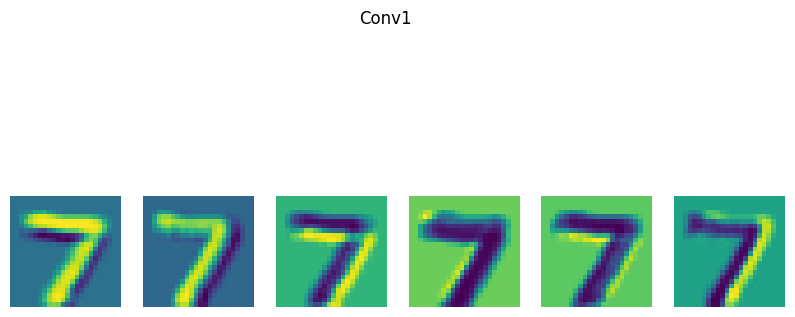

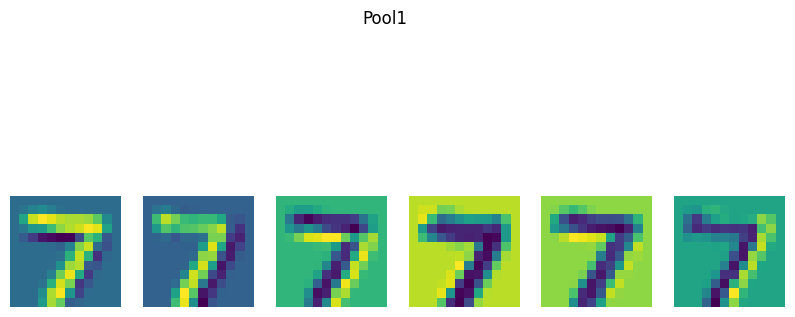

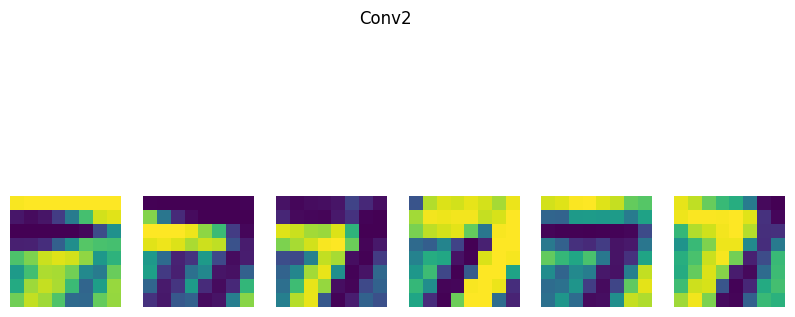

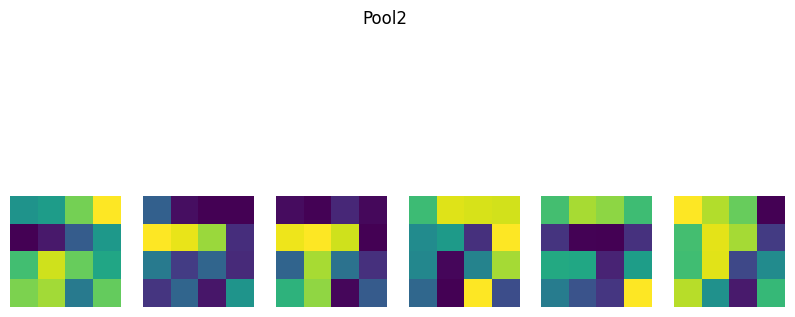

In [ ]:
#visualizing convolutions layers
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0
model = Sequential()
model.add(Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)))
model.add(AveragePooling2D((2,2)))
model.add(Conv2D(16, (5,5), activation='tanh'))
model.add(AveragePooling2D((2,2)))
model.add(Flatten())
model.add(Dense(120, activation='tanh'))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(X_train, y_train, epochs=2, batch_size=128)
layer_outputs = [layer.output for layer in model.layers[:4]]
activation_model = Model(inputs=model.layers[0].input, outputs=layer_outputs)
img = X_test[0].reshape(1,28,28,1)
activations = activation_model.predict(img)
layer_names = ['Conv1', 'Pool1', 'Conv2', 'Pool2']

for i in range(len(activations)):
    plt.figure(figsize=(10,5))
    plt.suptitle(layer_names[i])

    for j in range(min(6, activations[i].shape[-1])):
        plt.subplot(1,6,j+1)
        plt.imshow(activations[i][0,:,:,j], cmap='viridis')
        plt.axis('off')

    plt.show()

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.1565
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.2996
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3008
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3010
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3011
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.3012
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 2.3012
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3012
Epoch 9/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3012
Epoch 10/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3012
Epoch 11/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3012
Epoch 12/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3012
Epoch 13/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3012
Epoch 14/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.3012
Epoch 15/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

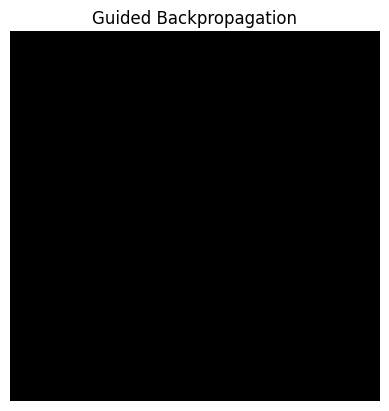

In [ ]:
#Guided Back Propogation
import tensorflow as tf
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense
import matplotlib.pyplot as plt
(x_train, y_train), _ = datasets.mnist.load_data()
x_train = x_train/255.0
x_train = x_train.reshape(-1,28,28,1)
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32") * dy
    return tf.nn.relu(x), grad
model = Sequential([
    keras.layers.Input(shape=(28,28,1)),
    Conv2D(8,(3,3),activation=guided_relu),
    Flatten(),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
model.fit(x_train, y_train, epochs=25, batch_size=128)
img = tf.convert_to_tensor(x_train[0:1])
with tf.GradientTape() as tape:
    tape.watch(img)
    preds = model(img)
    loss = preds[:, tf.argmax(preds[0])]
grads = tape.gradient(loss, img)
plt.imshow(grads[0,:,:,0], cmap='gray')
plt.title("Guided Backpropagation")
plt.axis('off')
plt.show()

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.2762 - val_loss: 0.1908
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1720 - val_loss: 0.1543
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1445 - val_loss: 0.1341
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1285 - val_loss: 0.1212
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1183 - val_loss: 0.1131
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1114 - val_loss: 0.1074
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1065 - val_loss: 0.1033
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1027 - val_loss: 0.0998
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0997 - val_loss: 0.0972
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0977 - val_loss: 0.0956
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0963 - val_loss: 0.0945
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

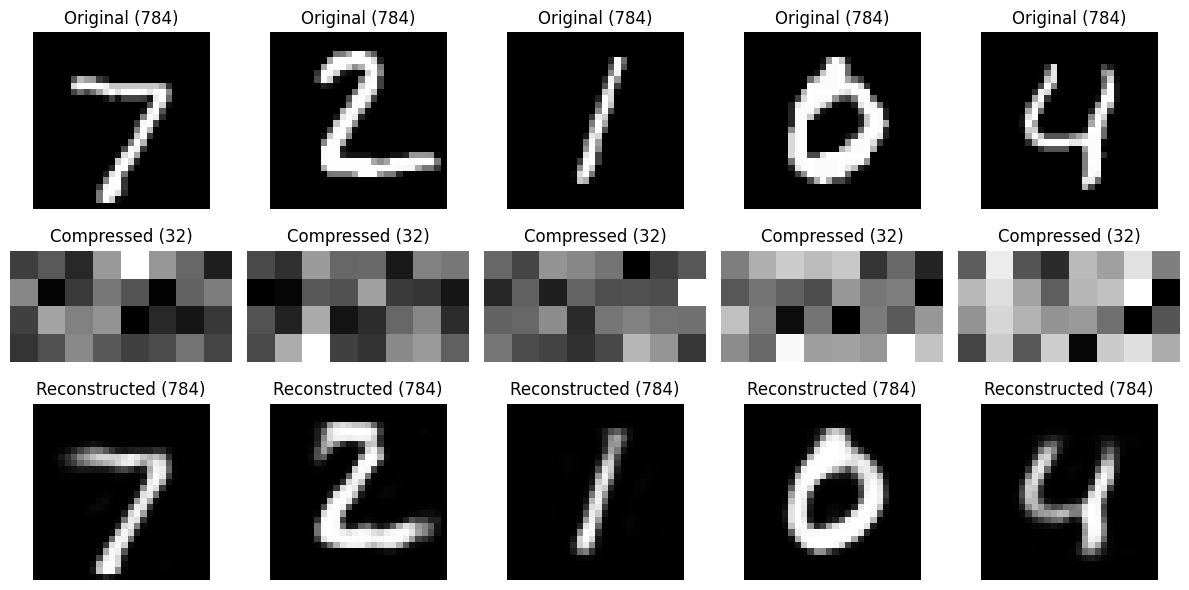

In [ ]:
#AutoEncoding
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))
input_dim = 784
encoding_dim = 32
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train,epochs=20,batch_size=256,shuffle=True,validation_data=(x_test, x_test))
encoded_imgs = encoder.predict(x_test)
decoded_imgs = autoencoder.predict(x_test)

n = 5
plt.figure(figsize=(12, 6))

for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title("Original (784)")
    plt.gray()
    ax.axis('off')
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(4, 8))
    plt.title("Compressed (32)")
    plt.gray()
    ax.axis('off')
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Reconstructed (784)")
    plt.gray()
    ax.axis('off')

plt.tight_layout()
plt.show()

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2151 - val_loss: 0.1338
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1161 - val_loss: 0.1013
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0955 - val_loss: 0.0885
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0856 - val_loss: 0.0814
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0799 - val_loss: 0.0770
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0763 - val_loss: 0.0743
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0740 - val_loss: 0.0724
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0723 - val_loss: 0.0712
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0711 - val_loss: 0.0702
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0702 - val_loss: 0.0695
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0695 - val_loss: 0.0688
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

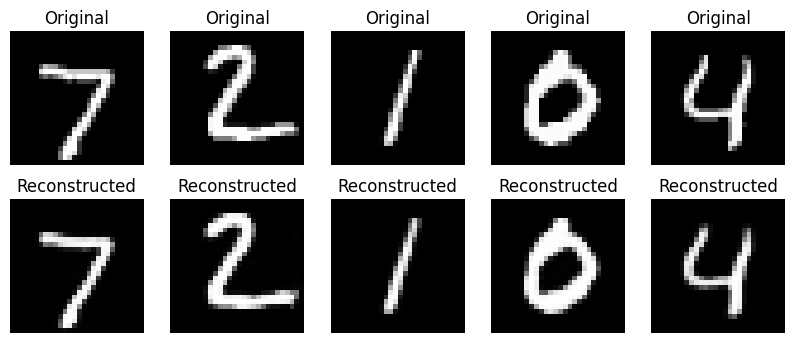

In [ ]:
#Under Complete AutoEncoding
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))
input_dim = 784
encoding_dim = 128
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train,epochs=20,batch_size=256,shuffle=True,validation_data=(x_test, x_test))
encoded_imgs = encoder.predict(x_test)
decoded_imgs = autoencoder.predict(x_test)

n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    # Original
    plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1486 - val_loss: 0.0853
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0874 - val_loss: 0.0737
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0805 - val_loss: 0.0705
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0777 - val_loss: 0.0689
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0762 - val_loss: 0.0682
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0752 - val_loss: 0.0675
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0745 - val_loss: 0.0671
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0740 - val_loss: 0.0668
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0736 - val_loss: 0.0666
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0733 - val_loss: 0.0664
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0730 - val_loss: 0.0662
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

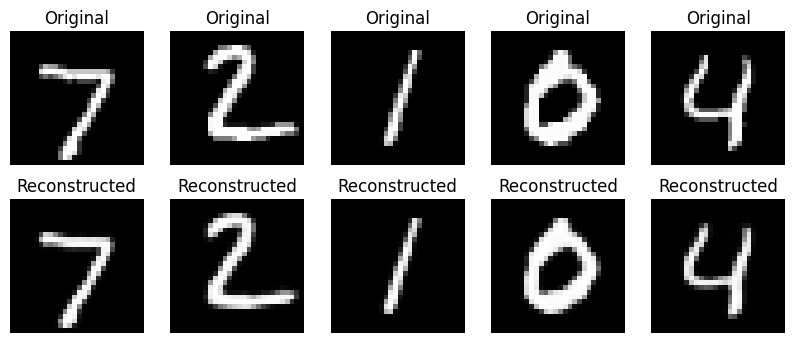

In [ ]:
#Over Complete AutoEncoding
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))
input_dim = 784
encoding_dim = 1024
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
encoded = Dropout(0.3)(encoded)
decoded = Dense(input_dim, activation='sigmoid')(encoded)
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train,epochs=20,batch_size=256,shuffle=True,validation_data=(x_test, x_test))
encoded_imgs = encoder.predict(x_test)
decoded_imgs = autoencoder.predict(x_test)

n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    # Original
    plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.3166 - val_loss: 0.2159
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2052 - val_loss: 0.1864
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1903 - val_loss: 0.1752
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1822 - val_loss: 0.1664
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1761 - val_loss: 0.1589
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1709 - val_loss: 0.1529
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1677 - val_loss: 0.1494
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1651 - val_loss: 0.1461
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1632 - val_loss: 0.1437
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1617 - val_loss: 0.1422
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


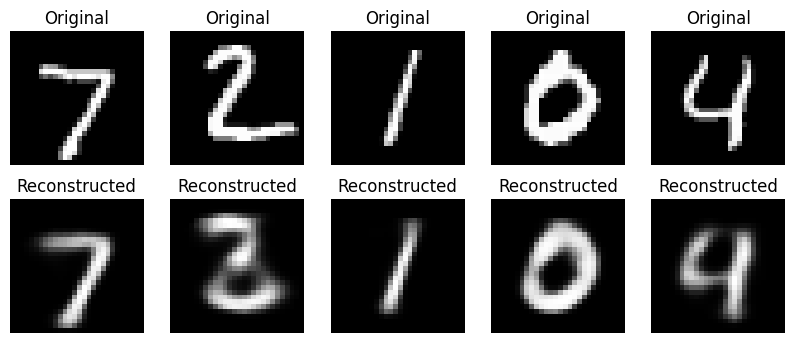

In [ ]:
#regularizations in autoencoders
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from tensorflow.keras.datasets import mnist
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
input_layer = Input(shape=(784,))
encoded = Dense(128,
                activation='relu',
                kernel_regularizer=regularizers.l2(1e-4),
                activity_regularizer=regularizers.l1(1e-5)
               )(input_layer)
encoded = Dropout(0.3)(encoded)
latent = Dense(32, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(latent)
output = Dense(784, activation='sigmoid')(decoded)
autoencoder = Model(input_layer, output)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train,epochs=10,batch_size=256,shuffle=True,validation_data=(x_test, x_test))
decoded_imgs = autoencoder.predict(x_test)
n = 5
plt.figure(figsize=(10,4))
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.2561 - val_loss: 0.1872
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1709 - val_loss: 0.1562
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1509 - val_loss: 0.1441
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1415 - val_loss: 0.1374
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1359 - val_loss: 0.1323
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


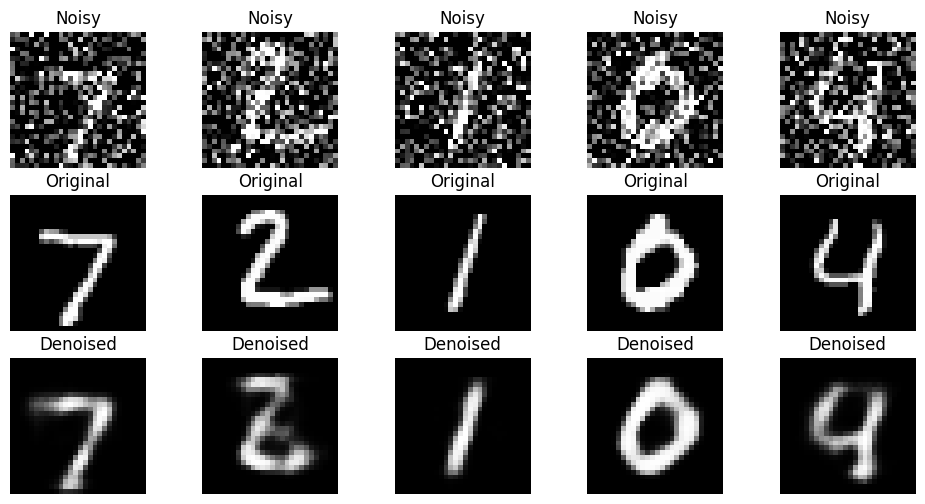

In [ ]:
#denoising autoencoders
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)
input_layer = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(encoded)
output = Dense(784, activation='sigmoid')(decoded)
autoencoder = Model(input_layer, output)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train_noisy, x_train,
                epochs=5,
                batch_size=256,
                validation_data=(x_test_noisy, x_test))
decoded_imgs = autoencoder.predict(x_test_noisy)
n = 5
plt.figure(figsize=(12,6))
for i in range(n):
    plt.subplot(3,n,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')
    plt.subplot(3,n,i+1+n)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(3,n,i+1+2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')
plt.show()

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2785 - val_loss: 0.1917
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1726 - val_loss: 0.1547
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1449 - val_loss: 0.1341
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1288 - val_loss: 0.1213
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1182 - val_loss: 0.1131
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


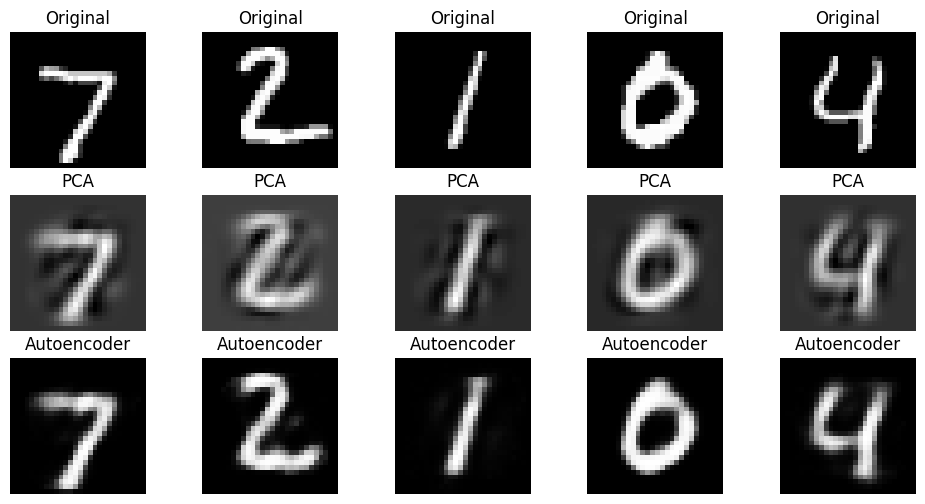

In [ ]:
#Demonstrate PCA with AE on a dataset.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
pca = PCA(n_components=32)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
x_test_pca_recon = pca.inverse_transform(x_test_pca)
input_layer = Input(shape=(784,))
encoded = Dense(32, activation='relu')(input_layer)
decoded = Dense(784, activation='sigmoid')(encoded)
autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train,epochs=5,batch_size=256,validation_data=(x_test, x_test))
x_test_ae_recon = autoencoder.predict(x_test)
n = 5
plt.figure(figsize=(12,6))
for i in range(n):
    plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(3,n,i+1+n)
    plt.imshow(x_test_pca_recon[i].reshape(28,28), cmap='gray')
    plt.title("PCA")
    plt.axis('off')
    plt.subplot(3,n,i+1+2*n)
    plt.imshow(x_test_ae_recon[i].reshape(28,28), cmap='gray')
    plt.title("Autoencoder")
    plt.axis('off')
plt.show()

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.4066 - val_loss: 0.2762
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2457 - val_loss: 0.2270
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2181 - val_loss: 0.2090
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2045 - val_loss: 0.1987
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1958 - val_loss: 0.1913
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1893 - val_loss: 0.1856
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1844 - val_loss: 0.1813
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1806 - val_loss: 0.1779
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1776 - val_loss: 0.1751
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1752 - val_loss: 0.1728


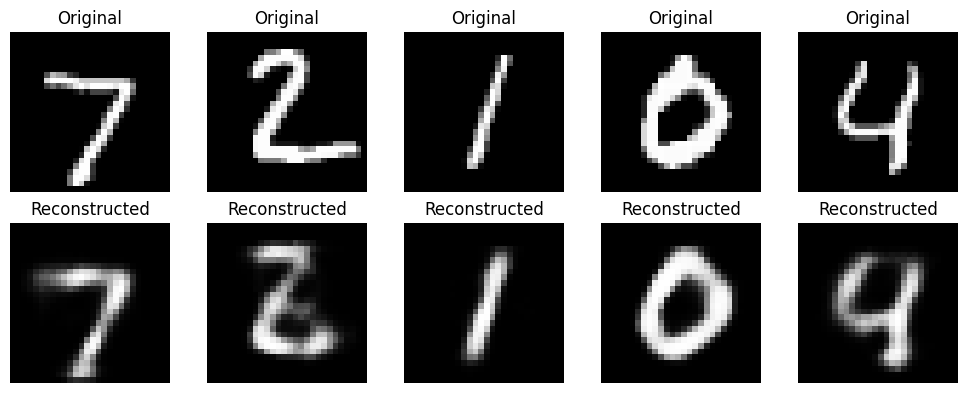

In [ ]:
#Sparse Autoencoder
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from tensorflow.keras.datasets import mnist
(x_train, _), (x_test, Y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
input_layer = Input(shape=(784,))
encoded = Dense(64, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_layer)
decoded = Dense(784, activation='sigmoid')(encoded)
model = Model(input_layer, decoded)
model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(x_train, x_train,epochs=10,batch_size=256,validation_data=(x_test, x_test))
n = 5
plt.figure(figsize=(10,4))
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.tight_layout()
plt.show()


Epoch 1, Loss: 0.2641889452934265
Epoch 2, Loss: 0.26089876890182495
Epoch 3, Loss: 0.25586193799972534
Epoch 4, Loss: 0.24679699540138245
Epoch 5, Loss: 0.2338765561580658
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


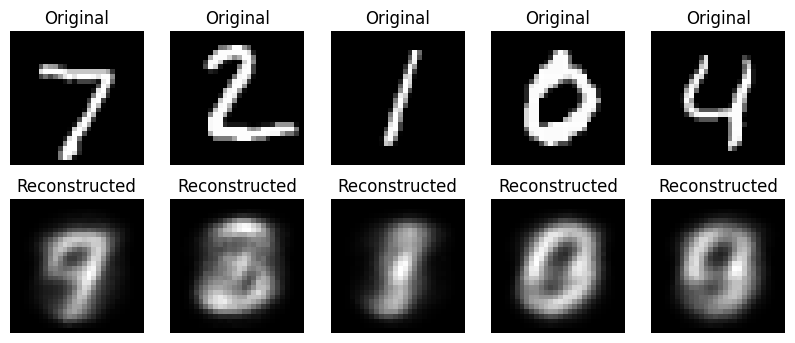

In [ ]:
#contractive Autoencoder
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
input_layer = Input(shape=(784,))
encoded = Dense(64, activation='sigmoid')(input_layer)
decoded = Dense(784, activation='sigmoid')(encoded)
model = Model(input_layer, decoded)
optimizer = tf.keras.optimizers.Adam()
lambda_val = 1e-4
epochs = 5
batch_size = 256
dataset = tf.data.Dataset.from_tensor_slices((x_train, x_train)).batch(batch_size)
for epoch in range(epochs):
    for x_batch, _ in dataset:
        with tf.GradientTape() as tape:
            encoded_out = model.layers[1](x_batch)
            decoded_out = model(x_batch)
            recon_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(x_batch, decoded_out)
            )
            W = model.layers[1].kernel
            dh = encoded_out * (1 - encoded_out)
            W_squared = tf.reduce_sum(tf.square(W), axis=0)
            dh_squared = tf.square(dh)
            contractive_loss = lambda_val * tf.reduce_mean(tf.reduce_sum(dh_squared * W_squared, axis=1))
            loss = recon_loss + contractive_loss
        grads = tape.gradient(loss, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))
    print(f"Epoch {epoch+1}, Loss: {loss.numpy()}")
decoded_imgs = model.predict(x_test)
n = 5
plt.figure(figsize=(10,4))
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()

In [ ]:
#Implement RNN for predicting the next character
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import numpy as np
vocab = ['d', 'e', 'p', '<stop>']
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for c, i in char2idx.items()}
sequence = ['d', 'e', 'p']
target = '<stop>'
X = np.eye(len(vocab))[[char2idx[c] for c in sequence]]
X = X.reshape(1, len(sequence), len(vocab))
y = np.eye(len(vocab))[char2idx[target]].reshape(1, len(vocab))
model = Sequential([
    SimpleRNN(8, input_shape=(3, len(vocab))),
    Dense(len(vocab), activation='softmax')
])
model.compile(loss='categorical_crossentropy', optimizer='adam')
model.fit(X, y, epochs=200, verbose=0)
test = X
pred = model.predict(test)
print("Predicted next char:", idx2char[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
Predicted next char: <stop>


In [ ]:
#Bert
from transformers import pipeline
classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
text = "I love this product!"
result = classifier(text)[0]
label = result['label']
binary_output = 1 if label == "POSITIVE" else 0
print("Text:", text)
print("Model Output:", result)
print("Binary Sentiment (1=Positive, 0=Negative):", binary_output)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Text: I love this product!
Model Output: {'label': 'POSITIVE', 'score': 0.9998855590820312}
Binary Sentiment (1=Positive, 0=Negative): 1


In [ ]:
#GAN on mnist dataset
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Reshape, Flatten
from tensorflow.keras.optimizers import Adam
(X_train, _), _ = mnist.load_data()
X_train = (X_train - 127.5) / 127.5  # Scale to [-1, 1]
X_train = X_train.reshape(-1, 784)
opt = Adam(0.0002, 0.5)
def build_generator():
    model = Sequential([
        Dense(128, input_dim=100),
        LeakyReLU(0.2),
        Dense(784, activation='tanh'),
    ])
    return model
def build_discriminator():
    model = Sequential([
        Dense(128, input_shape=(784,)),
        LeakyReLU(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model


generator = build_generator()
discriminator = build_discriminator()
noise = np.random.normal(0, 1, (128, 100))
fake_images = generator.predict(noise)
real_images = X_train[np.random.randint(0, X_train.shape[0], 128)]
real_labels = np.ones((128, 1))
fake_labels = np.zeros((128, 1))

d_loss_real = discriminator.train_on_batch(real_images, real_labels)
d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

print("Discriminator accuracy on real:", d_loss_real[1]*100)
print("Discriminator accuracy on fake:", d_loss_fake[1]*100)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
Discriminator accuracy on real: 3.125
Discriminator accuracy on fake: 40.234375
